In [42]:
import pandas as pd

df = pd.read_csv('data/processed/merged_data.csv')
df.shape

(113935, 39)

In [43]:
df.head(5)

,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,Ammonia shots(NH3_shots:kgs),Viscosity(Viscosity_offline:centPoise),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),Batch_ID,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault)
0,0.2,30,100,8,0.0000,30.118,9.8335,0.0001,0,0.6,...,0,NaN,0,0,1,1,1066400.0,1720000.0,2786400.0,0
1,0.4,30,100,8,0.0000,51.221,18.1550,0.0001,0,0.6,...,0,NaN,0,0,1,1,1066400.0,1720000.0,2786400.0,0
2,0.6,30,100,8,0.0000,54.302,9.5982,0.0001,0,0.6,...,0,NaN,0,0,1,1,1066400.0,1720000.0,2786400.0,0
3,0.8,30,100,8,0.0000,37.816,4.3395,0.0001,0,0.6,...,0,NaN,0,0,1,1,1066400.0,1720000.0,2786400.0,0
4,1.0,30,100,8,0.5181,18.908,1.1045,0.0001,0,0.6,...,0,4.083,0,0,1,1,1066400.0,1720000.0,2786400.0,0


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113935 entries, 0 to 113934
Data columns (total 39 columns):
 #   Column                                                              Non-Null Count   Dtype  
---  ------                                                              --------------   -----  
 0   Time (h)                                                            113935 non-null  float64
 1   Aeration rate(Fg:L/h)                                               113935 non-null  int64  
 2   Agitator RPM(RPM:RPM)                                               113935 non-null  int64  
 3   Sugar feed rate(Fs:L/h)                                             113935 non-null  int64  
 4   Acid flow rate(Fa:L/h)                                              113935 non-null  float64
 5   Base flow rate(Fb:L/h)                                              113935 non-null  float64
 6   Heating/cooling water flow rate(Fc:L/h)                             113935 non-null  float64
 7   Heating water

In [46]:
column_map = {
    # --- 1. 공정 상태 & 핵심 품질 변수 ---
    'Penicillin concentration(P:g/L)': '페니실린농도(g/L)',              # Y값 핵심 (실시간)
    'Substrate concentration(S:g/L)': '기질농도(g/L)',                   # X값 (골든배치 핵심 관제변수)
    'Dissolved oxygen concentration(DO2:mg/L)': '용존산소농도(mg/L)',
    'Vessel Volume(V:L)': '발효조부피(L)',
    'pH(pH:pH)': '수소이온농도(pH)',
    'Temperature(T:K)': '발효온도(K)',

    # --- 2. 실시간 공정 제어 및 상태 센서 변수 ---
    'Agitator RPM(RPM:RPM)': '교반기회전수(RPM)',
    'Sugar feed rate(Fs:L/h)': '당공급유량(L/h)',
    'Aeration rate(Fg:L/h)': '공기주입유량(L/h)',
    'Acid flow rate(Fa:L/h)': '산투입유량(L/h)',
    'Base flow rate(Fb:L/h)': '염기투입유량(L/h)',
    'Heating/cooling water flow rate(Fc:L/h)': '냉난방수유량(L/h)',       # 냉각 전용 아님, 냉난방 겸용
    'Heating water flow rate(Fh:L/h)': '가열전용유량(L/h)',
    'Water for injection/dilution(Fw:L/h)': '희석수투입유량(L/h)',
    'PAA flow(Fpaa:PAA flow (L/h))': 'PAA투입유량(L/h)',
    'Oil flow(Foil:L/hr)': '오일투입유량(L/h)',
    'Air head pressure(pressure:bar)': '상부기압(bar)',
    'Generated heat(Q:kJ)': '발생열량(kJ)',
    'Vessel Weight(Wt:Kg)': '발효조중량(kg)',
    'Dumped broth flow(Fremoved:L/h)': '배양액제거유량(L/h)',
    'Ammonia shots(NH3_shots:kgs)': '암모니아투입량(kg)',
    'carbon dioxide percent in off-gas(CO2outgas:%)': '배가스_CO2비율(%)',
    'Oxygen in percent in off-gas(O2:O2  (%))': '배가스_O2비율(%)',
    'Oxygen Uptake Rate(OUR:(g min^{-1}))': '산소소모율(g/min)',
    'Carbon evolution rate(CER:g/h)': '이산화탄소배출율(g/h)',

    # --- 3. 식별자, 제어 플래그 & 결함(Fault) 변수 (전부 X값 금지) ---
    'Batch_ID': '배치번호',
    'Batch ref': '배치번호_참조',                                        # Batch_ID와 100% 동일, Drop 권장
    'Time (h)': '발효시간(h)',
    'Fault ref(0-NoFault 1-Fault)': '결함여부_배치단위',                  # 넓은 정의(10.12%), 배치91~100=1
    'Fault reference(Fault_ref:Fault ref)': '결함여부_구간단위',          # 좁은 정의(1.1%), 이상 튀는 순간만=1
    '0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)': '제어원인플래그(0_Recipe_1_Operator)',

    # --- 4. 오프라인 측정 변수 (결측 98%+, 전부 X값 금지) ---
    'Offline Biomass concentratio(X_offline:X(g L^{-1}))': '바이오매스농도_오프라인(g/L)',
    'Offline Penicillin concentration(P_offline:P(g L^{-1}))': '페니실린농도_오프라인(g/L)',
    'PAA concentration offline(PAA_offline:PAA (g L^{-1}))': 'PAA농도_오프라인(g/L)',
    'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))': '암모니아농도_오프라인(g/L)',
    'Viscosity(Viscosity_offline:centPoise)': '점도_오프라인(cP)',

    # --- 5. 원본 수율 & 수확량 타겟 변수 (Merged Y 후보) ---
    'Penicllin_yield_total (kg)': '총수율(kg)',                          # Y값 핵심, CV 24.8% 메인 Y
    'Penicllin_harvested_end_of_batch (kg)': '종료시수확량(kg)',          # Y값 후보
    'Penicllin_harvested_during_batch(kg)': '중간수확량(kg)',            # Y값 후보
}

df = df.rename(columns=column_map)

# 참고: 'Control Strategy'(제어전략그룹)는 원본 컬럼이 아니라 Batch_ID로 파생해야 하는 변수예요.
# 테이블 가이드대로 만들면:
def batch_to_strategy(batch_id):
    if 1 <= batch_id <= 30:
        return 'RC'
    elif 31 <= batch_id <= 60:
        return 'OC'
    elif 61 <= batch_id <= 90:
        return 'APC'
    else:
        return 'Fault'

df['제어전략그룹'] = df['배치번호'].apply(batch_to_strategy)

df = df.rename(columns=column_map)
df.columns

Index(['발효시간(h)', '공기주입유량(L/h)', '교반기회전수(RPM)', '당공급유량(L/h)', '산투입유량(L/h)',
       '염기투입유량(L/h)', '냉난방수유량(L/h)', '가열전용유량(L/h)', '희석수투입유량(L/h)',
       '상부기압(bar)', '배양액제거유량(L/h)', '기질농도(g/L)', '용존산소농도(mg/L)', '페니실린농도(g/L)',
       '발효조부피(L)', '발효조중량(kg)', '수소이온농도(pH)', '발효온도(K)', '발생열량(kJ)',
       '배가스_CO2비율(%)', 'PAA투입유량(L/h)', 'PAA농도_오프라인(g/L)', '오일투입유량(L/h)',
       '암모니아농도_오프라인(g/L)', '산소소모율(g/min)', '배가스_O2비율(%)', '페니실린농도_오프라인(g/L)',
       '바이오매스농도_오프라인(g/L)', '이산화탄소배출율(g/h)', '암모니아투입량(kg)', '점도_오프라인(cP)',
       '결함여부_구간단위', '제어원인플래그(0_Recipe_1_Operator)', '배치번호', '배치번호_참조',
       '중간수확량(kg)', '종료시수확량(kg)', '총수율(kg)', '결함여부_배치단위', '제어전략그룹'],
      dtype='str')

In [47]:
df.isnull().sum()

발효시간(h)                              0
공기주입유량(L/h)                          0
교반기회전수(RPM)                          0
당공급유량(L/h)                           0
산투입유량(L/h)                           0
염기투입유량(L/h)                          0
냉난방수유량(L/h)                          0
가열전용유량(L/h)                          0
희석수투입유량(L/h)                         0
상부기압(bar)                            0
배양액제거유량(L/h)                         0
기질농도(g/L)                            0
용존산소농도(mg/L)                         0
페니실린농도(g/L)                          0
발효조부피(L)                             0
발효조중량(kg)                            0
수소이온농도(pH)                           0
발효온도(K)                              0
발생열량(kJ)                             0
배가스_CO2비율(%)                         0
PAA투입유량(L/h)                         0
PAA농도_오프라인(g/L)                 111873
오일투입유량(L/h)                          0
암모니아농도_오프라인(g/L)                111873
산소소모율(g/min)                         0
배가스_O2비율(%)              

In [48]:
df.describe()

,발효시간(h),공기주입유량(L/h),교반기회전수(RPM),당공급유량(L/h),산투입유량(L/h),염기투입유량(L/h),냉난방수유량(L/h),가열전용유량(L/h),희석수투입유량(L/h),상부기압(bar),...,암모니아투입량(kg),점도_오프라인(cP),결함여부_구간단위,제어원인플래그(0_Recipe_1_Operator),배치번호,배치번호_참조,중간수확량(kg),종료시수확량(kg),총수율(kg),결함여부_배치단위
count,113935.000000,113935.000000,113935.0,113935.000000,113935.000000,113935.000000,113935.000000,113935.000000,113935.000000,113935.000000,...,113935.0,2062.000000,113935.000000,113935.000000,113935.000000,113935.000000,1.139350e+05,1.139350e+05,1.139350e+05,113935.000000
mean,114.750656,65.246360,100.0,76.663764,0.073209,61.334389,74.346341,20.763025,154.811954,0.945026,...,0.0,51.546454,0.011024,0.301795,50.402466,50.402466,1.107013e+06,1.912159e+06,3.019180e+06,0.101154
std,66.990504,11.690215,0.0,25.680134,0.552788,44.972713,108.022600,50.230266,155.601474,0.134269,...,0.0,24.073778,0.104415,0.459039,28.862140,28.862140,2.668860e+05,5.825535e+05,7.509214e+05,0.301534
min,0.200000,20.000000,100.0,2.000000,0.000000,0.000000,0.000100,0.000100,0.000000,0.600000,...,0.0,4.075300,0.000000,0.000000,1.000000,1.000000,3.886500e+05,5.021800e+05,8.908300e+05,0.000000
25%,57.000000,60.000000,100.0,72.000000,0.000000,35.766000,11.157000,0.000100,0.000000,0.900000,...,0.0,34.812250,0.000000,0.000000,26.000000,26.000000,9.680200e+05,1.383100e+06,2.426300e+06,0.000000
50%,114.000000,65.000000,100.0,80.000000,0.000000,55.407000,34.384000,0.159010,100.000000,0.900000,...,0.0,53.154000,0.000000,0.000000,50.000000,50.000000,1.095100e+06,2.089700e+06,3.099500e+06,0.000000
75%,171.000000,75.000000,100.0,90.000000,0.000000,76.271500,94.904500,11.640500,250.000000,1.100000,...,0.0,73.536000,0.000000,1.000000,76.000000,76.000000,1.198300e+06,2.373400e+06,3.588600e+06,0.000000
max,290.000000,75.000000,100.0,150.000000,12.996000,225.000000,1500.000000,1500.000000,500.000000,1.100000,...,0.0,117.930000,1.000000,1.000000,100.000000,100.000000,2.089700e+06,2.932400e+06,4.447700e+06,1.000000


In [50]:
df['배치번호'].nunique()

100

In [ ]:
for col in df.columns:
    print(col, '→', df[col].nunique(), '개 고유값')

시간(h) → 1450 개 고유값
공기주입속도(L/h) → 7 개 고유값
교반속도(RPM) → 1 개 고유값
당분투입속도(L/h) → 25 개 고유값
산투입속도(L/h) → 1353 개 고유값
염기투입속도(L/h) → 67206 개 고유값
냉각수유량(L/h) → 77380 개 고유값
가열수유량(L/h) → 54534 개 고유값
희석수투입속도(L/h) → 6 개 고유값
공기압력(bar) → 6 개 고유값
배양액제거속도(L/h) → 2 개 고유값
영양분농도(g/L) → 64531 개 고유값
용존산소농도(mg/L) → 11087 개 고유값
페니실린농도(g/L) → 56258 개 고유값
배양조부피(L) → 28296 개 고유값
배양조무게(kg) → 31711 개 고유값
산도(pH) → 3990 개 고유값
온도(K) → 393 개 고유값
발생열량(kJ) → 51059 개 고유값
배출가스_이산화탄소비율(%) → 28416 개 고유값
PAA투입속도(L/h) → 22931 개 고유값
PAA농도_수동측정(g/L) → 1563 개 고유값
오일투입속도(L/h) → 9 개 고유값
암모니아농도_수동측정(g/L) → 1759 개 고유값
산소소비속도(g/min) → 35065 개 고유값
배출가스_산소비율(%) → 3095 개 고유값
페니실린농도_수동측정(g/L) → 1919 개 고유값
미생물농도_수동측정(g/L) → 1934 개 고유값
이산화탄소발생속도(g/h) → 35059 개 고유값
암모니아투입량(kg) → 1 개 고유값
점도_수동측정(cP) → 1976 개 고유값
결함여부_시간별기록 → 2 개 고유값
운전방식(0자동_1수동) → 2 개 고유값
배치일련번호 → 100 개 고유값
배치번호 → 100 개 고유값
배치중간수확량(kg) → 100 개 고유값
배치최종수확량(kg) → 100 개 고유값
총생산량(kg) → 100 개 고유값
결함여부_최종결과 → 2 개 고유값
제어전략그룹 → 4 개 고유값


In [ ]:
exclude_cols = [
    '배치일련번호', '결함여부_최종결과', 'Batch_ID', '시간(h)', '배치번호',
    '총생산량(kg)', '배치최종수확량(kg)', '배치중간수확량(kg)'  # 결과(outcome) 성격 컬럼
]
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude_cols)

group_mean = df.groupby('결함여부_최종결과')[numeric_cols].mean().T
group_mean['차이(절대값)'] = (group_mean[1] - group_mean[0]).abs()
group_mean = group_mean.sort_values('차이(절대값)', ascending=False)
print(group_mean.head(15))

결함여부_최종결과                    0             1      차이(절대값)
배양조무게(kg)         81297.699180  79113.205206  2184.493974
배양조부피(L)          73527.468030  71405.928243  2121.539788
PAA농도_수동측정(g/L)    1746.681446   3145.162596  1398.481151
암모니아농도_수동측정(g/L)   1918.719310   2346.226923   427.507613
냉각수유량(L/h)           70.980538    104.254531    33.273993
염기투입속도(L/h)          62.906020     47.369033    15.536988
영양분농도(g/L)            2.770178     15.717137    12.946959
가열수유량(L/h)           19.723115     30.003564    10.280449
페니실린농도_수동측정(g/L)     14.883912     10.477749     4.406163
페니실린농도(g/L)          14.759542     10.552140     4.207402
당분투입속도(L/h)          77.084416     72.925900     4.158515
발생열량(kJ)            278.761825    281.833734     3.071908
미생물농도_수동측정(g/L)      18.998255     17.023891     1.974364
점도_수동측정(cP)          51.348884     53.307488     1.958604
희석수투입속도(L/h)        154.706572    155.748373     1.041801


In [ ]:
df[['온도(K)', '산도(pH)', '교반속도(RPM)', '용존산소농도(mg/L)']].nunique()
df[['온도(K)', '산도(pH)', '교반속도(RPM)']].describe()

,온도(K),산도(pH),교반속도(RPM)
count,113935.000000,113935.000000,113935.0
mean,298.026489,6.496565,100.0
std,0.197513,0.065676,0.0
min,296.840000,5.395700,100.0
25%,297.950000,6.493200,100.0
50%,297.990000,6.500900,100.0
75%,298.040000,6.508600,100.0
max,302.180000,6.766400,100.0


In [65]:
batch = df.groupby('배치번호').agg(
    control_mode=('제어원인플래그(0_Recipe_1_Operator)', lambda x: x.mode()[0])
).reset_index()

batch['제어전략그룹'] = batch['배치번호'].apply(batch_to_strategy)  # RC/OC/APC/Fault

pd.crosstab(batch['제어전략그룹'], batch['control_mode'])

control_mode,0,1
제어전략그룹,,
APC,30,0
Fault,10,0
OC,0,30
RC,30,0


In [52]:
print(df.shape)
print(df.dtypes[['배치번호', '발효시간(h)']])

(113935, 40)
배치번호         int64
발효시간(h)    float64
dtype: object


In [53]:
time_diff = df.groupby('배치번호')['발효시간(h)'].diff()
print(time_diff.value_counts().head())

발효시간(h)
0.2    36800
0.2    36442
0.2    19812
0.2     9200
0.2     6400
Name: count, dtype: int64


In [54]:
print(time_diff.round(4).value_counts().head(10))

발효시간(h)
0.2    113835
Name: count, dtype: int64


시간간격 전부 12분 0.2시간 

In [56]:
batch_duration = df.groupby('배치번호')['발효시간(h)'].max()
print(batch_duration.describe())
print(batch_duration.value_counts().head(10))
batch_length = df.groupby('배치번호').size()
print(batch_length.describe())

count    100.000000
mean     227.870000
std       18.150691
min      167.000000
25%      227.500000
50%      230.000000
75%      230.000000
max      290.000000
Name: 발효시간(h), dtype: float64
발효시간(h)
230.0    51
231.0     3
225.0     3
232.0     2
228.0     2
211.0     2
210.0     2
235.0     2
241.0     2
226.0     1
Name: count, dtype: int64
count     100.000000
mean     1139.350000
std        90.753454
min       835.000000
25%      1137.500000
50%      1150.000000
75%      1150.000000
max      1450.000000
dtype: float64


배치마다 발효 시간이 동일한지, 다르다면 Time_pct 정렬이 왜 필요한지 확인
- 배치 지속시간: 최소 167h ~ 최대 290h (평균 227.9h, 표준편차 18.2h)
- 100개 배치 중 51개가 정확히 230h(1150행)에서 종료

 배치마다 길이가 다름 → 절대 시간이 아닌 `Time_pct`(공정진행률) 기준 정렬이 필요함을 확인. 

In [57]:
df.duplicated(subset=['배치번호','발효시간(h)']).sum()


np.int64(0)

같은 배치·같은 시간에 중복된 행 없음 , 중복 Timestamp 없음

In [58]:
df.isnull().sum().sort_values(ascending=False).head(10)

점도_오프라인(cP)                     111873
바이오매스농도_오프라인(g/L)               111873
암모니아농도_오프라인(g/L)                111873
페니실린농도_오프라인(g/L)                111873
PAA농도_오프라인(g/L)                 111873
중간수확량(kg)                            0
배치번호_참조                              0
배치번호                                 0
제어원인플래그(0_Recipe_1_Operator)         0
결함여부_구간단위                            0
dtype: int64

오프라인 측정 변수 5개(점도, 바이오매스, 암모니아, 페니실린, PAA)는 111,873개 결측 
—  컬럼 자체를 df에서 아예 뺴거나,  나중에 모델 피처 선택할 때 이 리스트에서 빼는 식(논문에서도 뻄)

In [59]:
df['공정진행률'] = df.groupby('배치번호')['발효시간(h)'].transform(lambda t: t / t.max())
df[['배치번호','발효시간(h)','공정진행률']].head()

,배치번호,발효시간(h),공정진행률
0,1,0.2,0.000885
1,1,0.4,0.001770
2,1,0.6,0.002655
3,1,0.8,0.003540
4,1,1.0,0.004425


공정진행률(Time_pct) 컬럼 생성
시간이 지날수록 1.0에 가까워 짐

In [60]:
df.groupby('제어전략그룹')[['기질농도(g/L)','페니실린농도(g/L)']].describe()

기질농도(g/L)                                                      \
           count       mean        std       min       25%       50%   
제어전략그룹                                                                 
APC      33700.0   0.087761   0.380756  0.000097  0.000947  0.001329   
Fault    11525.0  15.717137  26.566055  0.000211  0.001459  0.003095   
OC       34385.0   4.381573  12.309183  0.000006  0.001054  0.001881   
RC       34325.0   3.789541  11.717685  0.000109  0.001008  0.001656   

                            페니실린농도(g/L)                                      \
              75%       max       count       mean        std           min   
제어전략그룹                                                                        
APC      0.002080    3.2114     33700.0  15.409893  10.337331  3.694700e-26   
Fault   23.299000  115.2700     11525.0  10.552140   8.479154  9.031200e-04   
OC       0.028837   96.2650     34385.0  14.132835   9.571818  1.815400e-25   
RC       0.003020   83.9560     34325.0  14.748835  10.024134  1.017800e-25   

                                           
             25%      50%     75%     max  
제어전략그룹                                     
APC     5.675875  16.5600  24.688  33.209  
Fault   4.354400   8.5008  16.082  32.809  
OC      5.697600  14.5770  21.813  35.088  
RC      5.891700  15.1100  22.745  36.183

In [ ]:
전략별 비교
전략(모드)마다 정상 운전 패턴이 다름, 
골든배치 밴드는 전체를 섞지 말고 전략별로 나눠서 만들어야 함?

논문	                선정 기준
Frontiers 2024 	       하나의 전략 그룹(APC, 61~90번) 전체 사용
Biotechnol Bioeng 2025 의도적 결함 미주입 조건(정상온도군) 전체 사용
J Biotechnol 2015      개별 배치 단위로 "품질 좋음 + 결함 없음" 검증된 것만 선정



## 골든배치 선정 기준 옵션 비교

| 옵션 | 방법 | 장점 | 단점 |
| --- | --- | --- | --- |
| **A. 전체 섞어서 상위 20%** | 전략 무관하게 전체 배치 중 수율 상위 20% | 가장 단순함 | 전략별 정상범위 차이 무시 → 밴드 왜곡 위험 |
| **B. 전략별로 각각 골든배치** | RC/OC/APC/Fault 각 그룹 안에서 상위 수율 선정 | 전략별 정상범위 반영 + Fault 안의 우수배치(93,96,98)도 인정됨 | 밴드 4개 관리 필요, 대시보드 로직 추가 필요 |
| **C. 논문처럼 한 그룹(APC)만 기준** | APC(61~90번)만 골든배치로 쓰고 나머지는 이 기준과 비교 | 같은 데이터셋 선례 있음(Frontiers 2024), 밴드 1개라 단순함 | RC/OC가 원래 다르게 설계됐다면 항상 "이탈"처럼 보일 위험 |
| **D. Fault만 빼고 나머지 합쳐서 상위 수율** | RC+OC+APC 합쳐서 상위 20%, Fault 전략만 제외 | 의도적 결함 그룹은 뺀다는 논리는 있음 | 프로젝트의 핵심 문제의식(이진판정 한계)과 모순, 93/96/98 놓침 |

**참고**: 같은 데이터셋(IndPenSim)을 쓴 논문은 Frontiers 2024뿐이며, 이 논문은 옵션 C 방식을 사용함.


In [80]:
batch = df.groupby('배치번호').agg(
    control_mode=('제어원인플래그(0_Recipe_1_Operator)', lambda x: x.mode()[0]),
    총수율=('총수율(kg)', 'max')
).reset_index()

batch['제어전략그룹'] = batch['배치번호'].apply(batch_to_strategy)
batch.groupby('제어전략그룹')['총수율'].describe()

,count,mean,std,min,25%,50%,75%,max
제어전략그룹,,,,,,,,
APC,30.0,3.484283e+06,3.079801e+05,2830800.0,3295450.0,3479350.0,3744450.0,4044300.0
Fault,10.0,2.600203e+06,1.199611e+06,890830.0,1736100.0,2275950.0,3592275.0,4447700.0
OC,30.0,2.833113e+06,6.799292e+05,1474100.0,2400200.0,2792650.0,3244700.0,4196000.0
RC,30.0,2.912750e+06,7.675764e+05,1842400.0,2241875.0,2782050.0,3584025.0,4083100.0


In [81]:
autocorr_1 = df.groupby('배치번호')['페니실린농도(g/L)'].apply(lambda s: s.autocorr(1)).mean()
print(autocorr_1)

0.9999968334644903


— 모든 배치의 페니실린농도가 12분 전 값이랑 사실상 거의 똑같이 움직임

In [82]:
first_fault_time = df[df['결함여부_구간단위'] == 1].groupby('배치번호')['공정진행률'].min()
first_fault_time.describe()

count    10.000000
mean      0.184812
std       0.128459
min       0.077519
25%       0.086957
50%       0.091838
75%       0.326087
max       0.347826
Name: 공정진행률, dtype: float64

Fault가 시작되는 시점은 평균 공정진행률 18.5%, 중앙값 9.2%, 최댓값 34.8%로 전체 배치 초반 1/3 이내에 발생함. 남은 공정 시간(65~90%)이 충분히 남아있어, 실시간 조기 이탈 진단이 실질적으로 의미가 있는 접근

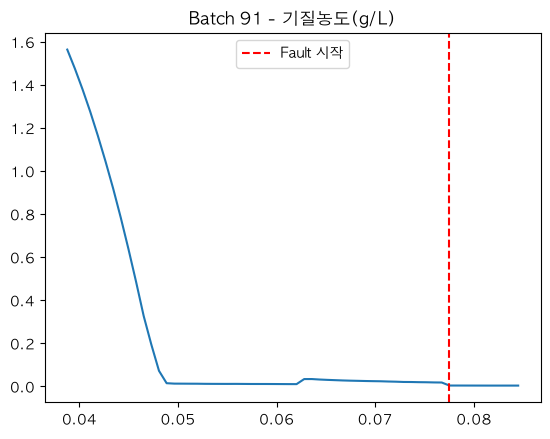

In [83]:
def plot_pre_fault_trend(df, batch_id, window=50, col='기질농도(g/L)'):
    sub = df[df['배치번호'] == batch_id].sort_values('발효시간(h)').reset_index(drop=True)
    fault_idx = sub[sub['결함여부_구간단위'] == 1].index.min()
    if pd.isna(fault_idx):
        print("이 배치는 Fault 없음")
        return
    start = max(0, fault_idx - window)
    view = sub.iloc[start:fault_idx + 10]
    plt.plot(view['공정진행률'], view[col])
    plt.axvline(sub.loc[fault_idx, '공정진행률'], color='red', linestyle='--', label='Fault 시작')
    plt.title(f'Batch {batch_id} - {col}')
    plt.legend()
    plt.show()

fault_batches = df[df['결함여부_구간단위'] == 1]['배치번호'].unique()
plot_pre_fault_trend(df, fault_batches[0])

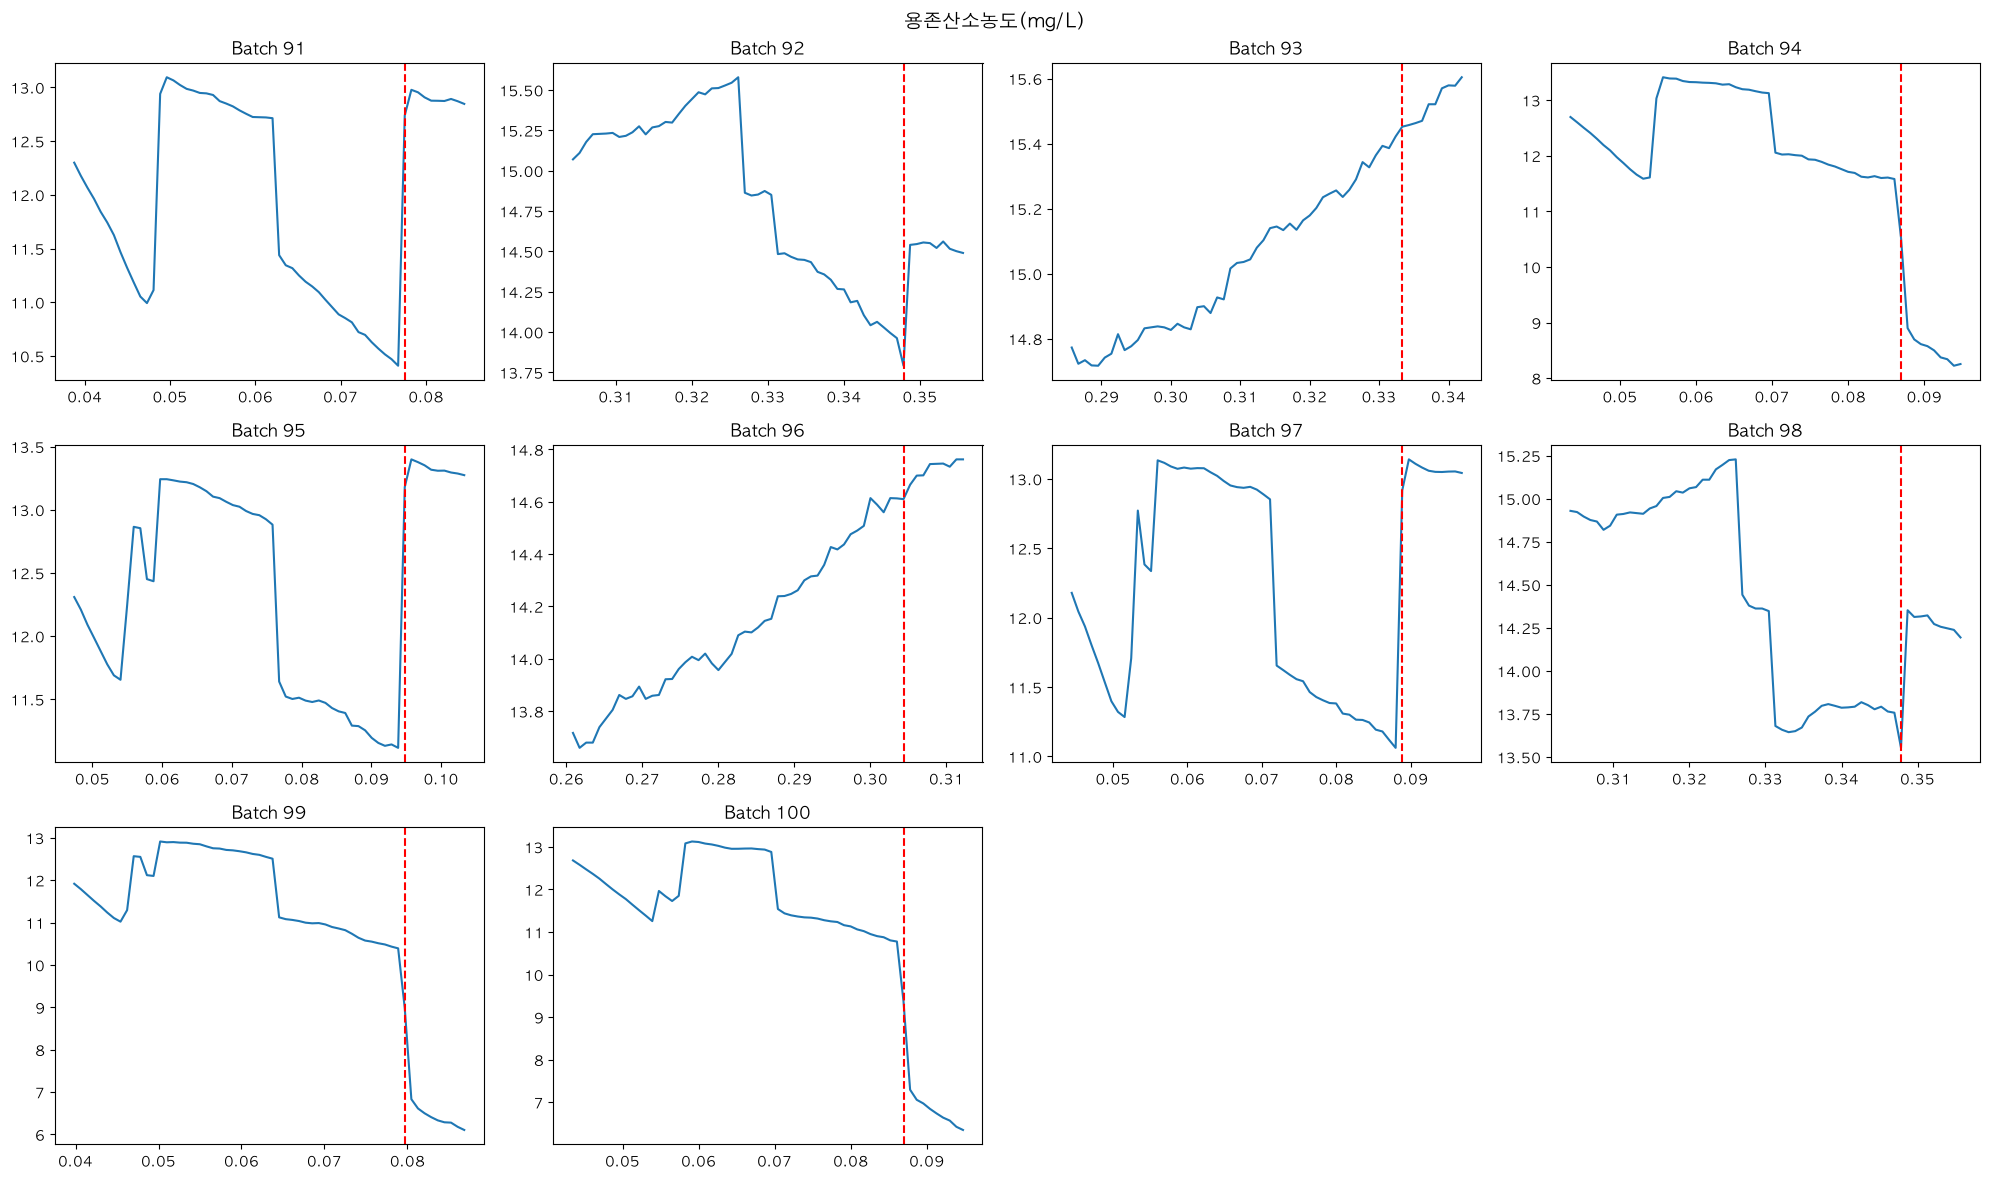

In [84]:
def plot_pre_fault_trend_grid(df, batch_ids, window=50, col='용존산소농도(mg/L)'):
    ncols = 4
    nrows = -(-len(batch_ids) // ncols)  # 올림 나눗셈
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    for ax, batch_id in zip(axes, batch_ids):
        sub = df[df['배치번호'] == batch_id].sort_values('발효시간(h)').reset_index(drop=True)
        fault_idx = sub[sub['결함여부_구간단위'] == 1].index.min()
        if pd.isna(fault_idx):
            ax.set_title(f'Batch {batch_id} - Fault 없음')
            ax.axis('off')
            continue
        start = max(0, fault_idx - window)
        view = sub.iloc[start:fault_idx + 10]
        ax.plot(view['공정진행률'], view[col])
        ax.axvline(sub.loc[fault_idx, '공정진행률'], color='red', linestyle='--')
        ax.set_title(f'Batch {batch_id}')

    for ax in axes[len(batch_ids):]:
        ax.axis('off')

    plt.suptitle(col, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_pre_fault_trend_grid(df, list(range(91, 101)), col='용존산소농도(mg/L)')

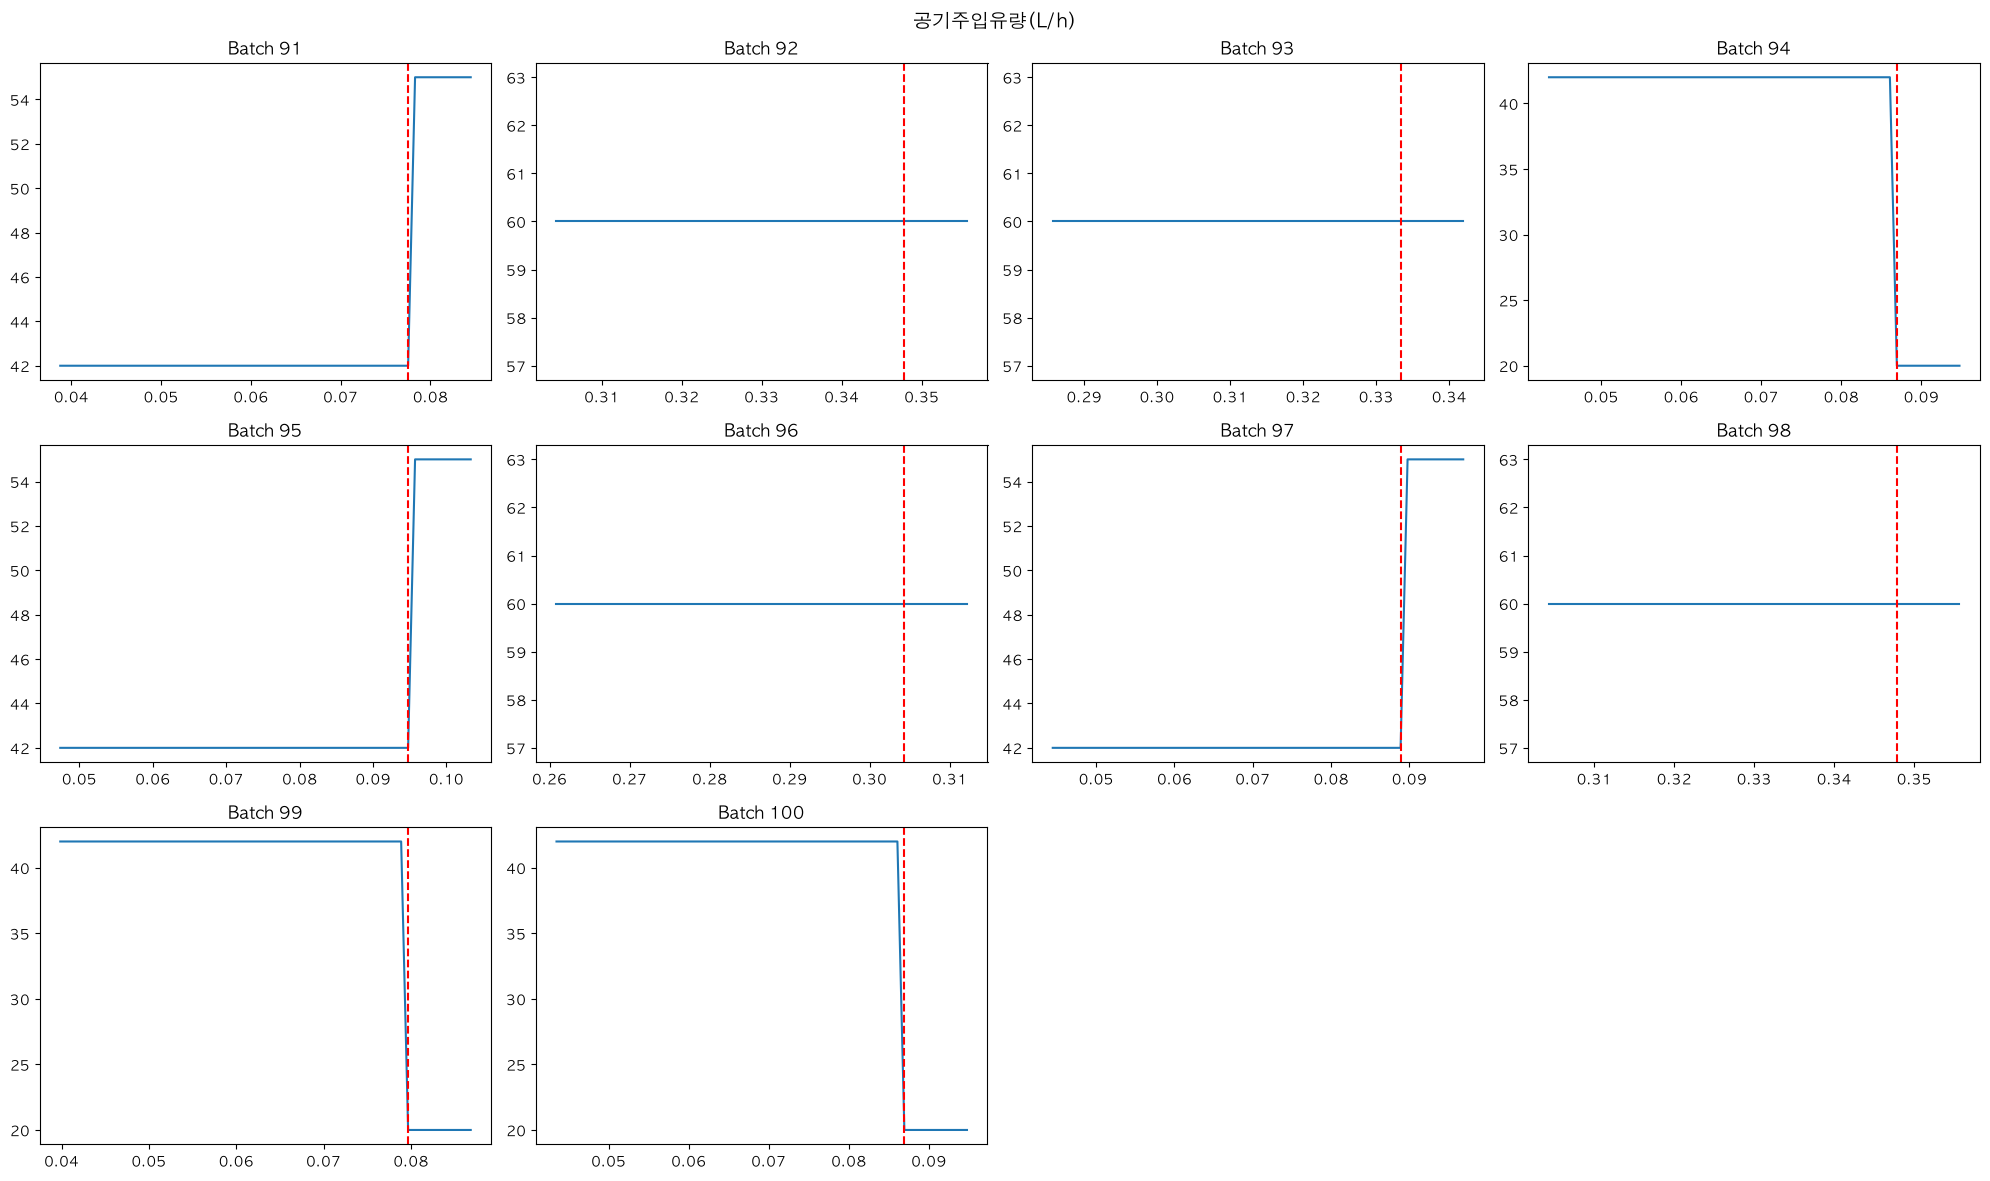

In [87]:
plot_pre_fault_trend_grid(df, list(range(91, 101)), col='공기주입유량(L/h)')

1) Fault 발생 시점
Fault가 시작되는 공정진행률은 평균 18.5%, 중앙값 9.2%, 최댓값 34.8%로 배치 초반 1/3 이내에 발생. 남은 공정 시간이 충분해 조기 감지의 실질적 여지가 있음.

2) 용존산소농도(DO2) — 조기경보 신호 후보
10개 Fault배치 중 7개(91,92,94,95,97,99,100)에서 Fault 시작 전 DO2가 서서히 하락하다가 Fault 시작 시점에 급등하는 패턴 확인. 93, 96번은 이 패턴이 없었고(이미 알려진 고성능 배치와 일치), 98은 완만한 중간 형태.

3) 통기율(공기주입유량) — 조기신호 아님, Fault 발생의 결과/마커
6개 배치(91,94,95,97,99,100)는 Fault 시작과 동시에 계단식으로 값이 바뀜(사전 변화 없음). 나머지 4개(92,93,96,98)는 전 구간 변화 없음 — 배치마다 다른 유형의 결함이 걸려있어 통기율에 영향을 주는 결함과 안 주는 결함이 나뉘는 것으로 추정.

4) 결론
DO2는 조기경보용 변수로 유망하나, 통기율은 사전 신호가 아니라 결함 발생 시점의 결과로 나타나는 값. Fault 라벨은 모델 학습에 직접 쓰지 않고, 이후 골든밴드 기반 이탈점수의 성능을 검증(Precision/Recall/Detection Delay)하는 데 사용할 예정

In [88]:
from sklearn.model_selection import GroupShuffleSplit
import json

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['배치번호']))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

train_batches = sorted(train_df['배치번호'].unique().tolist())
test_batches = sorted(test_df['배치번호'].unique().tolist())

print(f"Train 배치 수: {len(train_batches)}, Test 배치 수: {len(test_batches)}")
print(f"Train 행 수: {len(train_df)}, Test 행 수: {len(test_df)}")

with open('train_test_batches.json', 'w') as f:
    json.dump({'train': train_batches, 'test': test_batches}, f)

Train 배치 수: 80, Test 배치 수: 20
Train 행 수: 91220, Test 행 수: 22715


In [89]:
train_df['제어전략그룹'] = train_df['배치번호'].apply(batch_to_strategy)
test_df['제어전략그룹'] = test_df['배치번호'].apply(batch_to_strategy)

print("Train:", train_df.groupby('제어전략그룹')['배치번호'].nunique())
print("Test:", test_df.groupby('제어전략그룹')['배치번호'].nunique())

Train: 제어전략그룹
APC      24
Fault     9
OC       23
RC       24
Name: 배치번호, dtype: int64
Test: 제어전략그룹
APC      6
Fault    1
OC       7
RC       6
Name: 배치번호, dtype: int64


배치 단위로 80/20 분할(Train 80배치·91,220행, Test 20배치·22,715행), 원본 행수와 일치해 누락 없음 확인.

제어전략그룹 4개 모두 Test에 포함됨(APC 6, Fault 1, OC 7, RC 6). Fault그룹은 Test 1개뿐이라 성능평가는 참고용으로만 해석.
(❗이 배치 하나의 결과로 "Fault그룹 성능이 좋다/나쁘다" 일반화하면 안 됨. 최종 리포트에는 Fault그룹 결과를 "참고용"이라고 꼭 명시할 것.❗)

In [90]:
def get_golden_batches(train_df, strategy_col='제어전략그룹', batch_col='배치번호',
                        target_col='총수율(kg)', top_pct=0.2, min_batches=3):
    golden = []
    for strategy, group in train_df.groupby(strategy_col):
        batch_yield = group.groupby(batch_col)[target_col].max()
        n_select = max(min_batches, int(len(batch_yield) * top_pct))
        threshold = batch_yield.sort_values(ascending=False).iloc[n_select-1]
        golden += batch_yield[batch_yield >= threshold].index.tolist()
    return golden

golden_batches = get_golden_batches(train_df)
print(sorted(golden_batches))
print(f"골든배치 수: {len(golden_batches)}")

[8, 9, 12, 26, 52, 55, 57, 60, 63, 66, 83, 85, 93, 96, 97]
골든배치 수: 15
